In [1]:
import json
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
data_path = Path("../src/data/passages.json")

In [11]:
df = pd.read_json(data_path)
df

,id,title,author,difficulty,text
0,0,おはなし,夏目漱石,normal,当人が文学者になれというたのはよほどの自信があったからでしょう。\n\n私はそれでふっつりや...
1,1,草枕,夏目漱石,normal,We look before and after\n And pine for what i...
2,2,草枕,夏目漱石,normal,ただ机の上へ、こう開けて、開いた所をいい加減に読んでるんです」\n「それで面白いんですか」\...
3,3,草枕,夏目漱石,normal,そんなに年をとっても、やっぱり、惚れたの、腫れたの、にきびが出来たのってえ事が面白いんですか...
4,4,三四郎,夏目漱石,easy,しかしなんといったら破れるか、まるで分別が出なかった。\n\n小説などにある甘い言葉は使いた...
...,...,...,...,...,...
1995,1jf,宝島,佐々木直次郎,hard,「宝島」はロバート・ルーイス・スティーヴンスン（一八五○―一八九四）の最初の長篇小説であり、...
1996,1jg,宝島,佐々木直次郎,hard,しかし、第十五章の次で作者は恐らく行詰りを感じたのであろう、一度執筆を放棄したが、その冬を越...
1997,1jh,千曲川のスケッチ,島崎藤村,hard,何と言ってもあの頃は、古くからある文章の約束がまだ重く残って、言葉の感情とか、その陰影とかの...
1998,1ji,千曲川のスケッチ,島崎藤村,hard,ともあれ、他の当時の文学者の多くがまだ十八世紀の英吉利文学を目標としていた中で、独逸本国の方...


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id          2000 non-null   str  
 1   title       2000 non-null   str  
 2   author      2000 non-null   str  
 3   difficulty  2000 non-null   str  
 4   text        2000 non-null   str  
dtypes: str(5)
memory usage: 78.3 KB


In [13]:
df.drop(['difficulty'], axis=1)

,id,title,author,text
0,0,おはなし,夏目漱石,当人が文学者になれというたのはよほどの自信があったからでしょう。\n\n私はそれでふっつりや...
1,1,草枕,夏目漱石,We look before and after\n And pine for what i...
2,2,草枕,夏目漱石,ただ机の上へ、こう開けて、開いた所をいい加減に読んでるんです」\n「それで面白いんですか」\...
3,3,草枕,夏目漱石,そんなに年をとっても、やっぱり、惚れたの、腫れたの、にきびが出来たのってえ事が面白いんですか...
4,4,三四郎,夏目漱石,しかしなんといったら破れるか、まるで分別が出なかった。\n\n小説などにある甘い言葉は使いた...
...,...,...,...,...
1995,1jf,宝島,佐々木直次郎,「宝島」はロバート・ルーイス・スティーヴンスン（一八五○―一八九四）の最初の長篇小説であり、...
1996,1jg,宝島,佐々木直次郎,しかし、第十五章の次で作者は恐らく行詰りを感じたのであろう、一度執筆を放棄したが、その冬を越...
1997,1jh,千曲川のスケッチ,島崎藤村,何と言ってもあの頃は、古くからある文章の約束がまだ重く残って、言葉の感情とか、その陰影とかの...
1998,1ji,千曲川のスケッチ,島崎藤村,ともあれ、他の当時の文学者の多くがまだ十八世紀の英吉利文学を目標としていた中で、独逸本国の方...


In [14]:
features = []

for text in df['text']:
    text_length = len(text)
    seen = set()
    unique_kanjis = []
    kanjis = "".join(re.findall(r"[一-龯々]", text))
    for char in kanjis:
        if char not in seen:
            seen.add(char)
            unique_kanjis.append(char)
    kanjis_count = len(kanjis)
    unique_kanjis_count= len(unique_kanjis)
    kanji_ratio = kanjis_count/text_length*100
    unique_kanji_ratio = (unique_kanjis_count / kanjis_count * 100) if kanjis_count > 0 else 0

    features.append({
        "text_length": text_length,
        "kanjis_count": kanjis_count,
        "unique_kanjis_count": unique_kanjis_count,
        "kanji_ratio": kanji_ratio,
        "unique_kanji_ratio": unique_kanji_ratio,
    })

features_df = pd.DataFrame(features)

df = pd.concat([df.reset_index(drop=True), features_df], axis = 1)

In [15]:
print(df[["text_length", "kanjis_count", "kanji_ratio", "unique_kanji_ratio"]].describe())

       text_length  kanjis_count  kanji_ratio  unique_kanji_ratio
count   2000.00000   2000.000000  2000.000000         2000.000000
mean     798.19050    182.981500    22.936164           61.647491
std       83.29774     48.926558     5.692168            8.545736
min      295.00000     14.000000     4.745763           29.084967
25%      794.00000    156.000000    19.752392           56.658163
50%      824.00000    184.000000    22.895388           62.446209
75%      839.00000    213.250000    27.683099           67.336735
max      992.00000    347.000000    43.243243           90.804598


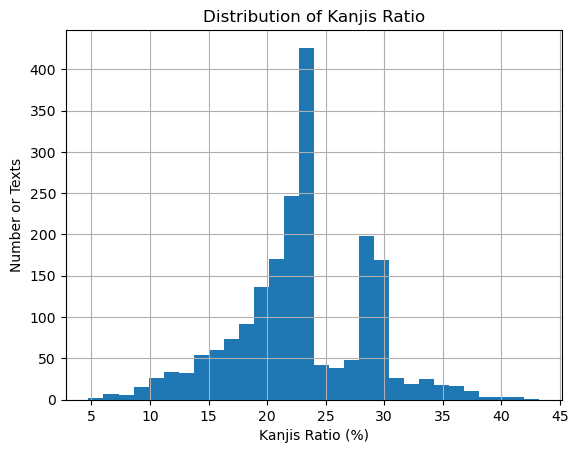

In [16]:
df["kanji_ratio"].hist(bins=30)
plt.title("Distribution of Kanjis Ratio")
plt.xlabel("Kanjis Ratio (%)")
plt.ylabel("Number or Texts")
plt.show()

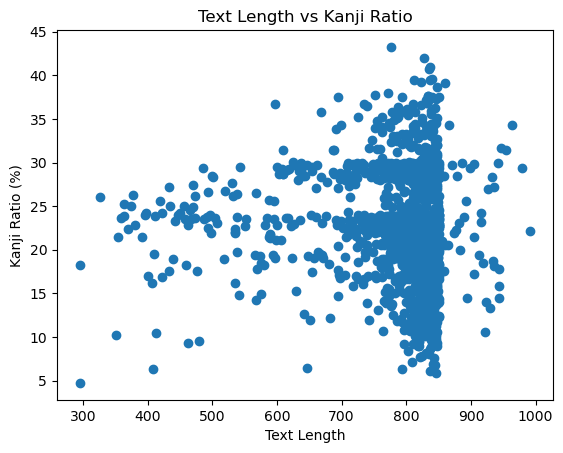

In [17]:
plt.scatter(df["text_length"], df["kanji_ratio"])
plt.title("Text Length vs Kanji Ratio")
plt.xlabel("Text Length")
plt.ylabel("Kanji Ratio (%)")
plt.show()

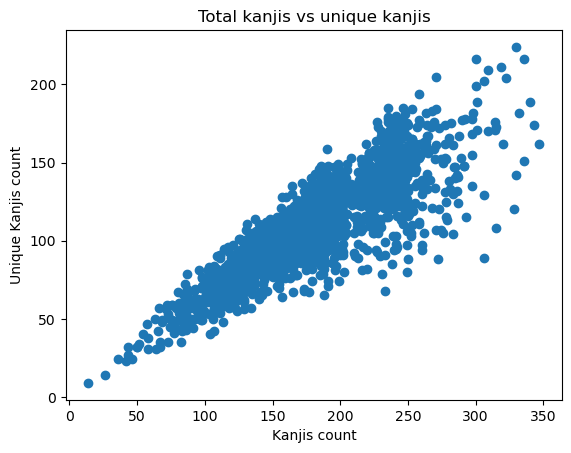

In [18]:
plt.scatter(df["kanjis_count"], df["unique_kanjis_count"])
plt.title("Total kanjis vs unique kanjis")
plt.xlabel("Kanjis count")
plt.ylabel("Unique Kanjis count")
plt.show()

In [25]:
df["difficulty_score"] = (
    df["kanji_ratio"] * 0.4 +
    df["unique_kanji_ratio"] * 0.6
)
df[["author","text", "difficulty_score"]].sort_values(by="difficulty_score", ascending=False).head()


,author,text,difficulty_score
1129,柳田国男,そうして少しでも以前のたしなみを持ち続けようとすると、まず目に留まったのはこのズズダマという...,63.640653
1443,中島敦,その年の秋、悟浄は、はたして、大唐の玄奘法師に値遇し奉り、その力で、水から出て人間となりかわ...,61.221083
1373,ルナールジュール,この時刻になると、歩きくたびれて、黒んぼの虫は散歩から帰って来、自分の屋敷の取散らかされてい...,60.297544
1469,ルナールジュール,草原に放すが否や、豚は食い始める。その鼻はもう決して地べたを離れない。\n 彼は柔らかい草を...,59.806452
1328,ロランロマン,一方は命令し抑圧する。\n\n他方は踠き呻く。\n\nけれどもこの二人の敵対者らは、征服者と...,59.208690


In [20]:
def difficulty_label(score):
    if score < 35:
        return "easy"
    elif score < 55:
        return "medium"
    else:
        return "hard"
df["difficulty_label"] = df["difficulty_score"].apply(difficulty_label)

df["difficulty_label"].value_counts()



difficulty_label
medium    1886
hard        64
easy        50
Name: count, dtype: int64

<Axes: xlabel='difficulty_label'>

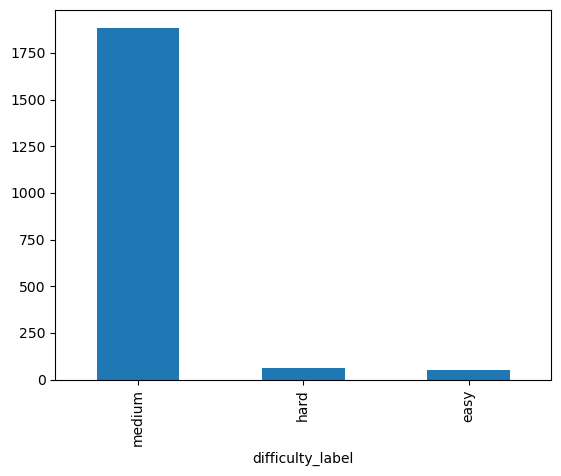

In [21]:
df["difficulty_label"].value_counts().plot(kind="bar")

In [22]:
df["author"]

0         夏目漱石
1         夏目漱石
2         夏目漱石
3         夏目漱石
4         夏目漱石
         ...  
1995    佐々木直次郎
1996    佐々木直次郎
1997      島崎藤村
1998      島崎藤村
1999       神西清
Name: author, Length: 2000, dtype: str

In [23]:
author_difficulty = df.groupby("author")["difficulty_score"].mean().sort_values(ascending=False)
print(author_difficulty)

author
原口統三        59.060341
小栗虫太郎       56.704294
渡辺温         56.523332
村崎敏郎        55.880495
山本周五郎       54.822780
              ...    
デカルトルネ      39.136994
菊池寛         39.124841
ペローシャルル     38.190481
新美南吉        36.421599
ダンセイニロード    32.174287
Name: difficulty_score, Length: 105, dtype: float64


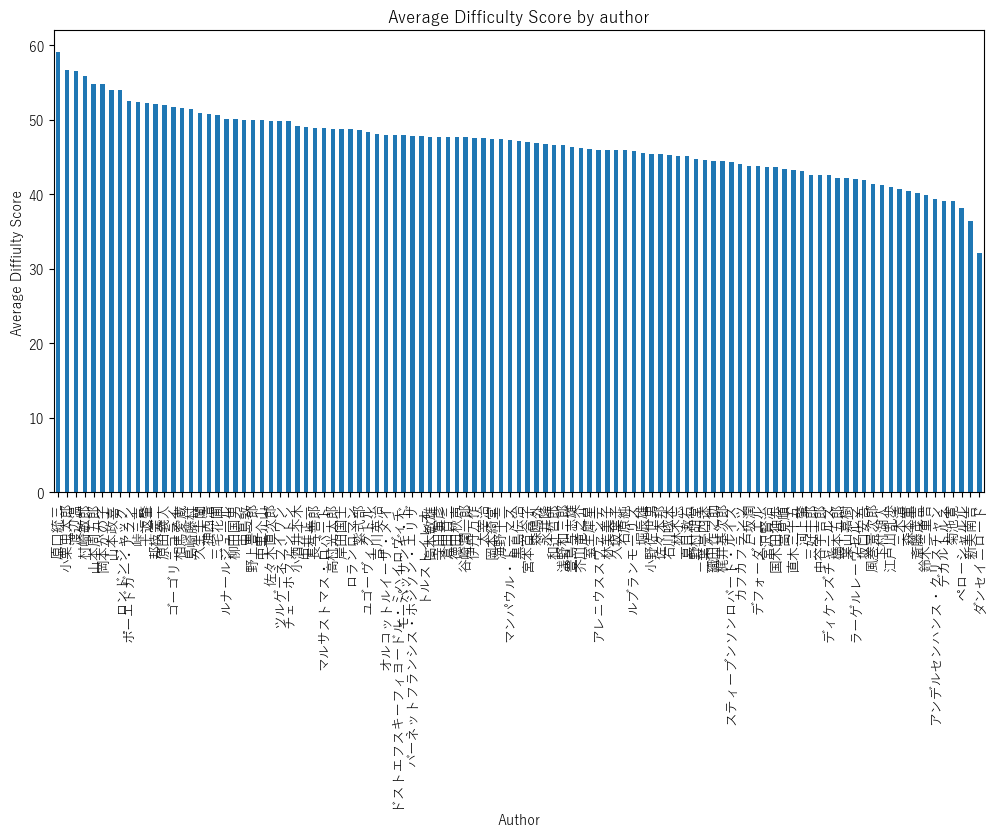

In [24]:
import matplotlib as mpl

mpl.rcParams["font.family"] = "Yu Gothic"

author_difficulty.plot(kind="bar", figsize=(12,6))
plt.title("Average Difficulty Score by author")
plt.xlabel("Author")
plt.ylabel("Average Diffiulty Score")
plt.show()